In [ ]:
import glob
import nibabel as nib
import matplotlib.pyplot as plt
from math import pi
from scipy.special import logsumexp
import numpy as np
import torch
import torch.nn.functional as F
import random
from scipy import stats
import tensorflow as tf
from tensorflow.python.client import device_lib
import os
from google.colab import drive
from scipy.stats import skew
from scipy.stats import kurtosis
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
drive.mount('/content/gdrive')

In [ ]:
torch.cuda.get_device_name(0)
tf.test.gpu_device_name()
# show GPU
!/opt/bin/nvidia-smi

Thu Dec 22 01:58:06 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   69C    P0    31W /  70W |    778MiB / 15109MiB |      1%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

# preprocess data

In [ ]:
# function to normalize the data
# Since the contrast of different modalities is different, use z-score to normalize the intensity
def normalize(data, ceil =99, floor=1):
    """normalize image with mean and std for regionnonzero,and clip the value into range"""
    
    # Remove the minimum and maximum intensity to make the data fairer
    c = np.percentile(data, ceil)
    f = np.percentile(data, floor)
    data = np.clip(data, f, c)# numpy.clip(a, a_min, a_max, out=None)
    
    # Normalize the intensity in the brain region 
    # except the black background
    image_nonzero = data[data != 0] # get all non-zero values
    if np.std(data) == 0 or np.std(image_nonzero) == 0:
        return data
    else:
        tmp = (data - np.mean(image_nonzero)) / np.std(image_nonzero)
        # since the range of intensities is between 0 and 5000 ,
        # the min in the normalized slice corresponds to 0 intensity in unnormalized slice
        # the min is replaced with -9 just to keep track of 0 intensities
        # so that we can discard those intensities afterwards when sampling random patches
        tmp[tmp == tmp.min()] = -9 # black background
        return tmp
      
# define the 3d kernel
# 3d convolution
def convolution(data):
    x,y,z = data.shape
    (k_x,k_y,k_z) = (3,3,3)
    start_point = round((k_x - 1)/2)
    img_new = np.zeros([x,y,z])# new image is all black
    for i in range(start_point,x - start_point): # x direction
        for j in range(start_point,y - start_point): # y direction
            for m in range(start_point,z - start_point): # z direction
                a = data[i-1:i+2, j-1:j+2, m-1:m+2]
                
                img_new[i,j,m] = np.mean(a)
                
    # fill the edges after convolution 
    for i in range(0,start_point):
        img_new[:,:,i] = img_new[:,:,start_point]
        img_new[:,:,z-1-i] = img_new[:,:,z-1-start_point]
        img_new[i,:,:] = img_new[start_point,:,:]
        img_new[x-1-i,:,:] = img_new[x-1-start_point,:,:]
        img_new[:,i,:] = img_new[:,start_point,:]
        img_new[:,y-1-i,:] = img_new[:,y-1-start_point,:]
        
    return img_new

def conv(data):
  data = np.expand_dims(data, axis=0)
  data_tensor = torch.from_numpy(data).float()
  data_tensor = data_tensor.to('cuda:0')
  p3d = (1, 1, 1, 1, 1, 1)
  data_tensor = torch.nn.functional.pad(data_tensor, p3d, "constant", -9)
  c = torch.nn.Conv3d(1, 1, (3, 3, 3), stride=1, padding=0, bias=False)
  c.weight.data = torch.Tensor([[[[[1/27, 1/27, 1/27],
                                [1/27, 1/27, 1/27],
                                [1/27, 1/27, 1/27]],
                               [[1/27, 1/27, 1/27],
                                [1/27, 1/27, 1/27],
                                [1/27, 1/27, 1/27]],
                               [[1/27, 1/27, 1/27],
                                [1/27, 1/27, 1/27],
                                [1/27, 1/27, 1/27]]]]])
  c.weight.data = c.weight.data.to('cuda:0')
  output_tensor = c(data_tensor).squeeze()
  output_np = output_tensor.cpu().detach().numpy()  
  return output_np

def convolution_skewness(data):
    x,y,z = data.shape
    (k_x,k_y,k_z) = (3,3,3)
    start_point = round((k_x - 1)/2)
    img_new = np.zeros([x,y,z])# new image is all black
    for i in range(start_point,x - start_point): # x direction
        for j in range(start_point,y - start_point): # y direction
            for m in range(start_point,z - start_point): # z direction
                a = data[i-1:i+2, j-1:j+2, m-1:m+2]
                a = np.reshape(a,(27,1))
                cuda0 = torch.device('cuda:0')
                array = torch.from_numpy(a).float().to(cuda0)
                mean = torch.mean(array)
                diffs = array - mean
                var = torch.mean(torch.pow(diffs, 2.0))
                std = torch.pow(var, 0.5)
                zscores = diffs / std
                skews = torch.mean(torch.pow(zscores, 3.0))
                img_new[i,j,m] = skews.item()
                
    # fill the edges after convolution 
    for i in range(0,start_point):
        img_new[:,:,i] = img_new[:,:,start_point]
        img_new[:,:,z-1-i] = img_new[:,:,z-1-start_point]
        img_new[i,:,:] = img_new[start_point,:,:]
        img_new[x-1-i,:,:] = img_new[x-1-start_point,:,:]
        img_new[:,i,:] = img_new[:,start_point,:]
        img_new[:,y-1-i,:] = img_new[:,y-1-start_point,:]
        
    return img_new

def convolution_kurtosis(data):
    x,y,z = data.shape
    (k_x,k_y,k_z) = (3,3,3)
    start_point = round((k_x - 1)/2)
    img_new = np.zeros([x,y,z])# new image is all black
    for i in range(start_point,x - start_point): # x direction
        for j in range(start_point,y - start_point): # y direction
            for m in range(start_point,z - start_point): # z direction
                a = data[i-1:i+2, j-1:j+2, m-1:m+2]
                a = np.reshape(a,(27,1))
                cuda0 = torch.device('cuda:0')
                array = torch.from_numpy(a).float().to(cuda0)
                mean = torch.mean(array)
                diffs = array - mean
                var = torch.mean(torch.pow(diffs, 2.0))
                std = torch.pow(var, 0.5)
                zscores = diffs / std
                kurtoses = torch.mean(torch.pow(zscores, 4.0)) - 3.0 
                img_new[i,j,m] = kurtoses.item()
                
    # fill the edges after convolution 
    for i in range(0,start_point):
        img_new[:,:,i] = img_new[:,:,start_point]
        img_new[:,:,z-1-i] = img_new[:,:,z-1-start_point]
        img_new[i,:,:] = img_new[start_point,:,:]
        img_new[x-1-i,:,:] = img_new[x-1-start_point,:,:]
        img_new[:,i,:] = img_new[:,start_point,:]
        img_new[:,y-1-i,:] = img_new[:,y-1-start_point,:]
        
    return img_new

# function to show the data
def datashow(data):
    width, height, queue = data.shape
    # print("width",width)  # 240
    # print("height",height) # 240
    # print("queue",queue)   # 155
    num = 1
    plt.subplots_adjust(wspace=0, hspace=0.1,right = 1, top =1, left = 0, bottom = 0)
    for i in range(0,queue,10): 
        img_arr = data[:,:,i]
        plt.subplot(5,4,num)
        plt.axis('off')
        plt.imshow(img_arr,cmap='gray')
        num +=1

    plt.show()

def PCA(X,k):
  mu = np.mean(X,axis=0)
  X -= mu
  U,s,Vh = np.linalg.svd(X)
  W = Vh[:k]
  Z = X*np.transpose(W)
  return Z

def preprocess(t1,t2,flair,t1ce,seg,index):
  # Load data
  img_seg = nib.load(seg[index])
  img_t1 = nib.load(t1[index])
  img_t2 = nib.load(t2[index])
  img_flair = nib.load(flair[index])
  img_t1ce = nib.load(t1ce[index])

  # Convert to array
  data_seg = img_seg.get_fdata()
  data_t1 = img_t1.get_fdata()
  data_t2 = img_t2.get_fdata()
  data_flair = img_flair.get_fdata()
  data_t1ce = img_t1ce.get_fdata()

  # Normolize the t1, t2,t1ce, fair
  data_t1_nor = normalize(data_t1, ceil =99, floor=1)
  data_t2_nor = normalize(data_t2, ceil =99, floor=1)
  data_flair_nor = normalize(data_flair, ceil =99, floor=1)
  data_t1ce_nor = normalize(data_t1ce, ceil =99, floor=1)

  # Extract convolutional features
  data_t1_conv = conv(data_t1_nor)
  data_t2_conv = conv(data_t2_nor)
  data_flair_conv = conv(data_flair_nor)
  data_t1ce_conv = conv(data_t1ce_nor)

  # Merge multimodal 3D data into one 4D data
  FourD_Array = np.zeros((data_t1_nor.shape[0],data_t1_nor.shape[1],data_t1_nor.shape[2],4),float)
  FourD_Array[:,:,:,0] = data_t1_conv # t1 data
  FourD_Array[:,:,:,1] = data_t2_conv # t2 data
  FourD_Array[:,:,:,2] = data_flair_conv # flair data
  FourD_Array[:,:,:,3] = data_t1ce_conv # t1ce data

  # build a training dataset (240x240x155) x 4
  dataset = FourD_Array.reshape(240*240*155,4)

  # tumor =1, background = 0
  data_seg[data_seg != 0] = 1
  return dataset,data_seg
    


# Method1: K-Means

In [ ]:
def Kmeans(dataset,k):
  ''' input 
      dataset: N x d, d is the # of feature
      k: k is the # of clusters
      output
      kmeans_y: 240 x 240 x 155, clustering result
      cluster_centers: k x d 
  '''
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(dataset)
  y_kmeans = kmeans.predict(dataset)
  kmeans_y = y_kmeans.reshape(240,240,155)
  cluster_centers = kmeans.cluster_centers_
  return kmeans_y, cluster_centers

def run_kmeans(dataset,k):
  '''input 
      dataset: N x d, d is the # of feature
      k: k is the # of clusters
      output
      output_k1: only has the voxel with same label a
      output_k2: only has the voxel with same label b
      a,b may be one of CSF and WT
  '''
  output_kmeans, k_cluster_centers = Kmeans(dataset,k)
  output_k1,output_k2 = keep_csf_tumor(output_kmeans)
  print('label_1')
  datashow(output_k1)
  print('label_2')
  datashow(output_k2)
  #return output_kmeans
  return output_k1, output_k2 , k_cluster_centers

# Method 2: GMM-EM

In [ ]:
class GMM(torch.nn.Module):

    def __init__(self, n_components, n_features, mu_init=None, var_init=None):
       
        super(GMM, self).__init__()

        self.n_components = n_components
        self.n_features = n_features
        self.log_llhood = -np.inf

        # initialize mu
        if mu_init is not None:
            self.mu = torch.nn.Parameter(mu_init, requires_grad=False)
        else:
            self.mu = torch.nn.Parameter(torch.randn(1, self.n_components, self.n_features), requires_grad=False)

        # initialize variance
        if var_init is not None:
            self.var = torch.nn.Parameter(var_init, requires_grad=False)
        else:
            self.var = torch.nn.Parameter(torch.eye(self.n_features).reshape(1, 1, self.n_features, self.n_features).repeat(1, self.n_components, 1, 1),requires_grad=False)

        # initialize pi
        self.pi = torch.nn.Parameter(torch.Tensor(1, self.n_components, 1), requires_grad=False).fill_(1. / self.n_components)

    def fit(self, x, n_iter=100, delta=1e-3, eps=1.e-6):
  
        if len(x.size()) == 2:
          x = x.unsqueeze(1)

        i = 0
        j = np.inf

        while (i <= n_iter) and (j >= delta):

            log_llhood_old = self.log_llhood
            mu_old = self.mu
            var_old = self.var

            # E-step
            weighted_p = self.log_p(x, self.mu, self.var) + torch.log(self.pi)
            log_w = weighted_p - torch.logsumexp(weighted_p, dim=1, keepdim=True)
            self.log_llhood = torch.logsumexp(weighted_p, dim=1).mean()

            # M-step
            w = torch.exp(log_w)
            pi = torch.sum(w, dim=0, keepdim=True) + eps
            mu = torch.sum(w * x, dim=0, keepdim=True) / pi
            var = torch.sum((x - mu).unsqueeze(-1).matmul((x - mu).unsqueeze(-2)) * w.unsqueeze(-1), dim=0, keepdim=True) / torch.sum(w, dim=0, keepdim=True).unsqueeze(-1) + (torch.eye(self.n_features) * eps).to(x.device)
            self.pi.data = pi / x.shape[0]
            self.mu.data = mu
            self.var.data = var
            
            i += 1
            j = self.log_llhood - log_llhood_old

            # When score decreases, revert to old parameters
            if j <= delta:
                self.mu = mu_old
                self.var = var_old

        return self.pi.data, self.mu.data, self.var.data

    def log_p(self, x, mu, var):

        precision = torch.inverse(var)
        d = x.shape[-1]

        log_pi = d * np.log(2. * 3.141592695)

        log_det = torch.empty(size=(self.n_components,)).to(precision.device)

        for k in range(self.n_components):
            log_det[k] = 2 * torch.log(torch.diagonal(torch.linalg.cholesky(precision[0,k]))).sum()

        log_det = log_det.unsqueeze(-1)

        x_mu_T = (x - mu).unsqueeze(-2)
        x_mu = (x - mu).unsqueeze(-1)

        x_T = torch.zeros(x_mu_T.shape).to(x_mu_T.device)  
        for i in range(self.n_components):
            a_i = x_mu_T[:, i, :, :].squeeze(-2)
            b_i = precision[0, i, :, :].squeeze()
            x_T[:, i, :, :] = a_i.mm(b_i).unsqueeze(1)

        x_T_x = torch.sum(x_T.squeeze(-2) * x_mu.squeeze(-1), dim=2, keepdim=True)

        return -.5 * (log_pi - log_det + x_T_x)

    def predict(self, x, pi, mu, var):

        if len(x.size()) == 2:
            x = x.unsqueeze(1)

        weighted_p = self.log_p(x, mu, var) + torch.log(pi)

        return torch.squeeze(torch.max(weighted_p, 1)[1].type(torch.LongTensor))

In [ ]:
def run_gmm(dataset,k,d,initial_mu):
  # note: must run kmeans first, because the initial mu is the result of kmeans
  # use the result of kmeans to be the initial mu of GMM
  ''' dataset: input data
      k: # of clusters
      d: # of features
      initial_mu: initial mean value
  '''
  initial_mu = np.reshape(initial_mu,(1,k,d))
  # convert to tensor
  initial_mu_tensor = torch.from_numpy(initial_mu).float()
  initial_mu_tensor = initial_mu_tensor.to('cuda:0')

  # covert dataset to tensor
  dataset_tensor = torch.from_numpy(dataset).float()
  # use GPU
  dataset_tensor = dataset_tensor.to('cuda:0')
  # number of features for each voxel  
  # number of clusters 
  n_components = k
  # GMM model
  # use the result of kmeans to be the initial mu
  model = GMM(n_components, d,mu_init = initial_mu_tensor)
  model.cuda()
  pi, mu, var = model.fit(dataset_tensor)
  y = model.predict(dataset_tensor,pi, mu, var)
  # convert tensor to numpy array
  y = y.cpu().detach().numpy()
  gmm_y = y.reshape(240,240,155)
  #datashow(gmm_y)

  output_g1,output_g2 = keep_csf_tumor(gmm_y)
  print('label_1')
  datashow(output_g1)
  print('label_2')
  datashow(output_g2)
  #return gmm_y
  return output_g1, output_g2

# remove other tissue and background, only keep tumor and csf

In [ ]:
# function to remove other cluster for black backgroud
def keep_csf_tumor(data1):
    data = data1.copy()
    # k: number of the clusters
    x,y,z = data.shape
    # find the label of black background
    # random choose 5 slices and pick the voxel at 4 corners
    # the mode of the labels of these 20 voxel is black background
    label_vec = np.zeros(20)
    for i in range(5):
        z_index = random.sample(range(z),1)
        label_vec[i*4] = data[0,0,z_index]
        label_vec[i*4+1] = data[0,239,z_index]
        label_vec[i*4+2] = data[239,0,z_index]
        label_vec[i*4+3] = data[239,239,z_index]
    mode_label_background = int(stats.mode(label_vec)[0])
    cluster_label = np.unique(data)
    # remove the label of background from the cluster label vector
    cluster_lable_new = [i for i in cluster_label if i !=mode_label_background]
    cluster_lable_new = np.array(cluster_lable_new)

    data_array = data.reshape(x*y*z)
    data_list = data_array.tolist()
    num_voxel_vec = np.zeros(len(cluster_lable_new))
    for i in range(len(cluster_lable_new)):
        num_voxel_vec[i] = data_list.count(cluster_lable_new[i])
    prob_label_vec = num_voxel_vec/np.sum(num_voxel_vec)
    label_with_prob = np.transpose(np.matrix([cluster_lable_new,prob_label_vec]))
    label_gm_wm = cluster_lable_new[np.argmax(prob_label_vec)]
    label_edges = cluster_lable_new[np.argmin(prob_label_vec)]
    
    for i in range(len(data_array)):
        if data_array[i] == label_gm_wm:
            data_array[i] = mode_label_background
        elif data_array[i] == label_edges:
            data_array[i] = mode_label_background
    [label_1, label_2] = np.unique(data_array)[np.unique(data_array) != mode_label_background]
    new_array_1 = data_array.copy()
    new_array_2 = data_array.copy()
    new_array_1[new_array_1 != label_1] = mode_label_background
    new_array_2[new_array_2 != label_2] = mode_label_background
    output_img_1 = new_array_1.reshape(x,y,z)
    output_img_2 = new_array_2.reshape(x,y,z)
    return output_img_1,output_img_2

# Metric


In [ ]:
def binary_dice(s, g):
    """
    calculate the Dice score of two N-d volumes.
    s: the segmentation volume of numpy array
    g: the ground truth volume of numpy array
    """
    array_s = np.reshape(s, (1,240*240*155))
    array_g = np.reshape(g, (1,240*240*155))
    assert (len(s.shape), len(g.shape))
    prod = np.multiply(s, g)
    s0 = prod.sum()
    dice = (2.0 * s0 + 1e-10) / (s.sum() + g.sum() + 1e-10)
    return dice

def binary_sens(s,g):
    """
    calculate the Sensitivity score of two N-d volumes.
    s: the segmentation volume of numpy array
    g: the ground truth volume of numpy array
    """
    array_s = np.reshape(s, (1,240*240*155))
    array_g = np.reshape(g, (1,240*240*155))
    assert (len(s.shape), len(g.shape))
    prod = np.multiply(s, g)
    sens = (prod.sum()+1e-10)/(g.sum()+1e-10)
    return sens

def binary_prec(s,g):
    """
    calculate the Precision score of two N-d volumes.
    s: the segmentation volume of numpy array
    g: the ground truth volume of numpy array
    """
    array_s = np.reshape(s, (1,240*240*155))
    array_g = np.reshape(g, (1,240*240*155))
    assert (len(s.shape), len(g.shape))
    prod = np.multiply(s, g)
    prec = (prod.sum()+1e-10)/(s.sum()+1e-10)
    return prec
  
def scores(output,data_seg):
  output [output != 0] = 1
  dice = binary_dice(output, data_seg)
  sens = binary_sens(output, data_seg)
  prec = binary_prec(output, data_seg)
  return dice, sens, prec

<>:9: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:23: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:36: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:9: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:23: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:36: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<ipython-input-7-33ced1047797>:9: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (len(s.shape), len(g.shape))
<ipython-input-7-33ced1047797>:23: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (len(s.shape), len(g.shape))
<ipython-input-7-33ced1047797>:36: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (len(s.shape), len(g.shape))


# Result

In [ ]:
def save_seg(new_y,name):
  # save numpy as .nii file
  converted_array = np.array(new_y, dtype=np.float32)
  nifti_file = nib.Nifti1Image(converted_array, affine=np.eye(4))
  nib.save(nifti_file, '/content/gdrive/Shareddrives/562project/562project/test/'+name+'_seg.nii')
  
def result(data_path, k, d):
  t1 = glob.glob(data_path + '/*/*_t1.nii.gz')
  t2 = glob.glob(data_path + '/*/*_t2.nii.gz')
  flair = glob.glob(data_path + '/*/*_flair.nii.gz')
  t1ce = glob.glob(data_path + '/*/*_t1ce.nii.gz')
  seg = glob.glob(data_path + '/*/*_seg.nii.gz')
  print(t1)
  for i in range(len(t1)):
    print(t1[i])
    dataset, data_seg = preprocess(t1,t2,flair,t1ce,seg,i)
    print("K-Means")
    output_k1, output_k2 , k_cluster_centers = run_kmeans(dataset, k)
    dice_k1, sens_k1, prec_k1 = scores(output_k1, data_seg)
    print("K,label 1: Dice = %s, Sens = %s, Prec = %s" %(dice_k1,sens_k1,prec_k1))
    dice_k2, sens_k2, prec_k2 = scores(output_k2, data_seg)
    print("K,label 2: Dice = %s, Sens = %s, Prec = %s" %(dice_k2,sens_k2,prec_k2))
    print()
    print("GMM-EM")
    output_g1, output_g2 = run_gmm(dataset, k, d, k_cluster_centers)
    dice_g1, sens_g1, prec_g1 = scores(output_g1, data_seg)
    print("G,label 1: Dice = %s, Sens = %s, Prec = %s" %(dice_g1,sens_g1,prec_g1))
    dice_g2, sens_g2, prec_g2 = scores(output_g2, data_seg)
    print("G,label 2: Dice = %s, Sens = %s, Prec = %s" %(dice_g2,sens_g2,prec_g2))

In [ ]:
dir_path = '/content/gdrive/Shareddrives/562project'
data_path = dir_path + '/562project/562_project_dataset/random'

['/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA01_401_1/Brats18_TCIA01_401_1_t1.nii.gz', '/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA03_474_1/Brats18_TCIA03_474_1_t1.nii.gz', '/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA05_478_1/Brats18_TCIA05_478_1_t1.nii.gz', '/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA08_469_1/Brats18_TCIA08_469_1_t1.nii.gz', '/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA04_437_1/Brats18_TCIA04_437_1_t1.nii.gz', '/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA06_184_1/Brats18_TCIA06_184_1_t1.nii.gz', '/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA08_162_1/Brats18_TCIA08_162_1_t1.nii.gz', '/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA06_165_1/Brats18_TCIA06_165_1_t1.nii.gz', '/content/gdrive/Shared

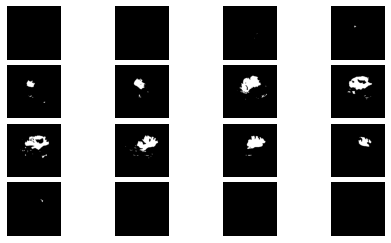

label_2


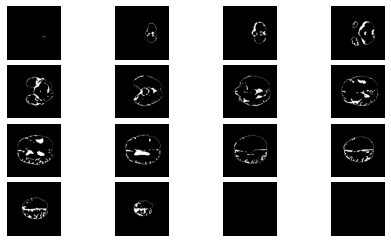

K,label 1: Dice = 0.04873762962928967, Sens = 1.0, Prec = 0.024977486559139794
K,label 2: Dice = 0.04873762962928967, Sens = 1.0, Prec = 0.024977486559139794

GMM-EM
label_1


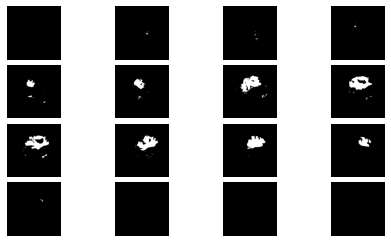

label_2


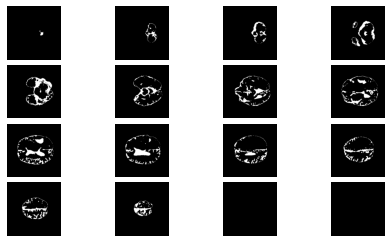

G,label 1: Dice = 0.04873762962928967, Sens = 1.0, Prec = 0.024977486559139794
G,label 2: Dice = 0.04873762962928967, Sens = 1.0, Prec = 0.024977486559139794
/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA03_474_1/Brats18_TCIA03_474_1_t1.nii.gz
K-Means
label_1


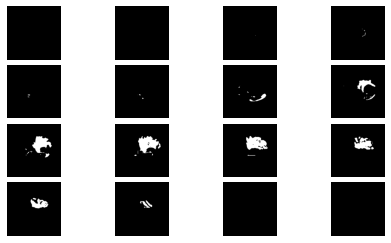

label_2


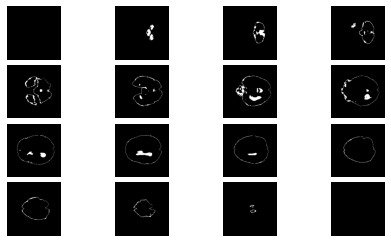

K,label 1: Dice = 0.9044437044077289, Sens = 0.9025197201820175, Prec = 0.9063759092259948
K,label 2: Dice = 0.011867446751207943, Sens = 0.010046862720366844, Prec = 0.014493869324226659

GMM-EM
label_1


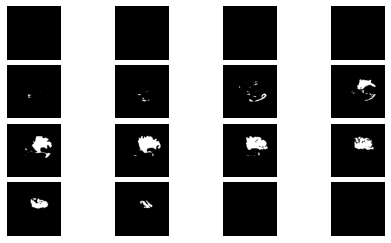

label_2


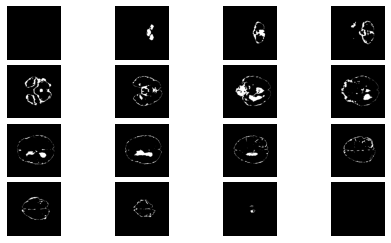

G,label 1: Dice = 0.8907969574453506, Sens = 0.9459429303268748, Prec = 0.8417265255378665
G,label 2: Dice = 0.03814702792769971, Sens = 0.04087147195513645, Prec = 0.035763101817657406
/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA05_478_1/Brats18_TCIA05_478_1_t1.nii.gz
K-Means
label_1


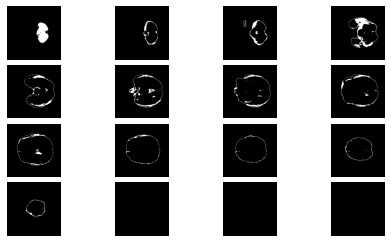

label_2


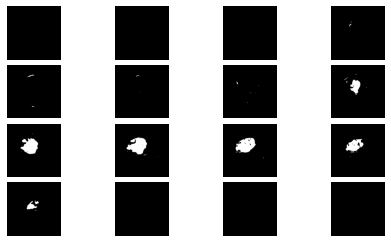

K,label 1: Dice = 0.008266570608976221, Sens = 0.007835670243893209, Prec = 0.008747621114487548
K,label 2: Dice = 0.9006821770881487, Sens = 0.8400765622741388, Prec = 0.9707122369284998

GMM-EM
label_1


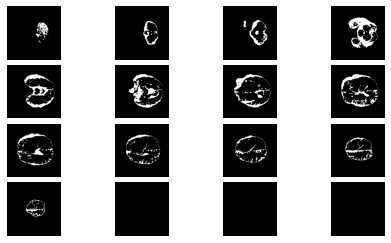

label_2


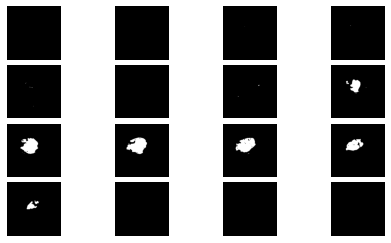

G,label 1: Dice = 0.06260141465032691, Sens = 0.10442077349828827, Prec = 0.04469968698056824
G,label 2: Dice = 0.9145856820364905, Sens = 0.847154585013533, Prec = 0.9936797670693063
/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA08_469_1/Brats18_TCIA08_469_1_t1.nii.gz
K-Means
label_1


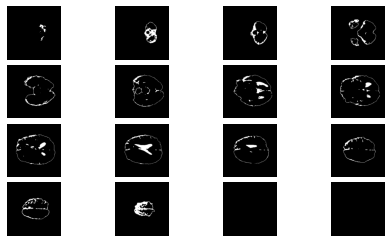

label_2


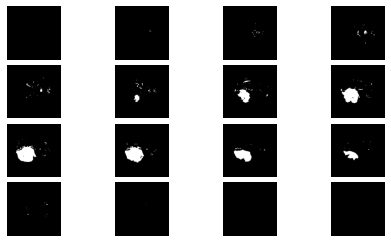

K,label 1: Dice = 0.012716361066483887, Sens = 0.013699434983990065, Prec = 0.011864931452245979
K,label 2: Dice = 0.8848960497955791, Sens = 0.8965247108821888, Prec = 0.8735651925003579

GMM-EM
label_1


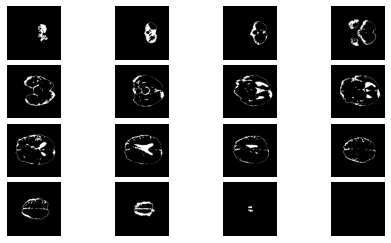

label_2


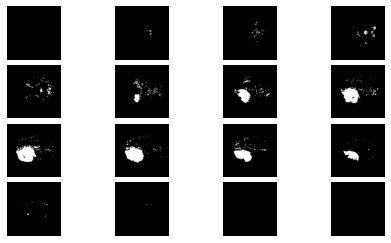

G,label 1: Dice = 0.023249414806801618, Sens = 0.03019946925705828, Prec = 0.01889983821150199
G,label 2: Dice = 0.8316677964619187, Sens = 0.9310768598035664, Prec = 0.7514383485861509
/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA04_437_1/Brats18_TCIA04_437_1_t1.nii.gz
K-Means
label_1


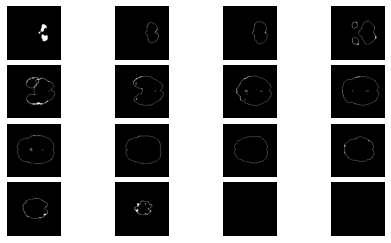

label_2


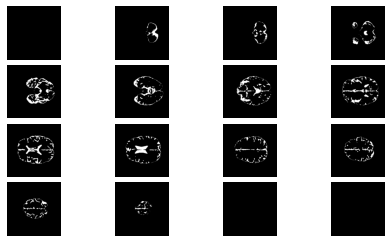

K,label 1: Dice = 0.009921787709498314, Sens = 0.026510628134708464, Prec = 0.006102925005499496
K,label 2: Dice = 0.008554290063755993, Sens = 0.07314306185813786, Prec = 0.0045427912392738195

GMM-EM
label_1


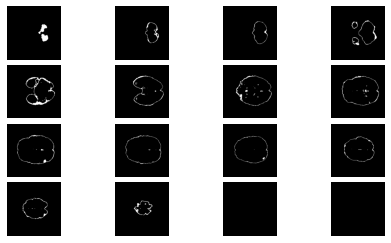

label_2


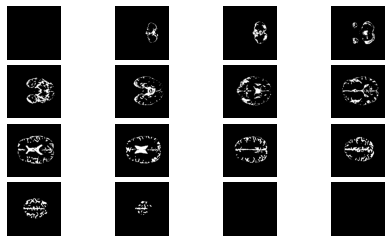

G,label 1: Dice = 0.04210001952191568, Sens = 0.18670886075949855, Prec = 0.023724801408162924
G,label 2: Dice = 0.04081866620081259, Sens = 0.446441366133273, Prec = 0.021387055068020095
/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA06_184_1/Brats18_TCIA06_184_1_t1.nii.gz
K-Means
label_1


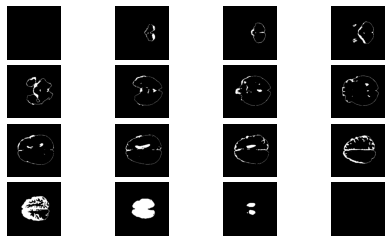

label_2


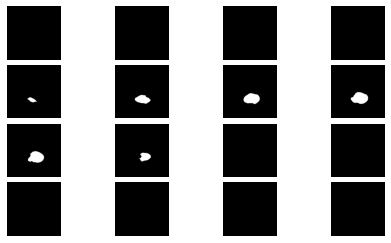

K,label 1: Dice = 0.002038642105285399, Sens = 0.0027661653110379637, Prec = 0.0016141167268235038
K,label 2: Dice = 0.8007682406064197, Sens = 0.6678329622392878, Prec = 0.9997789153245693

GMM-EM
label_1


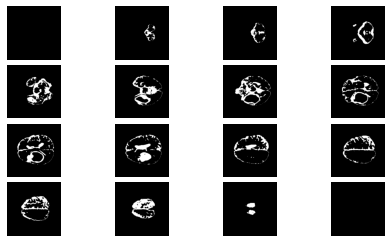

label_2


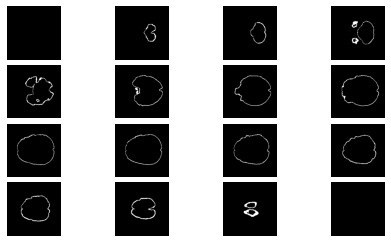

G,label 1: Dice = 0.23710496917345608, Sens = 0.43218634979779197, Prec = 0.16336490174145127
G,label 2: Dice = 0.0005893513827208788, Sens = 0.0005566410687514198, Prec = 0.0006261460709340435
/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA08_162_1/Brats18_TCIA08_162_1_t1.nii.gz
K-Means
label_1


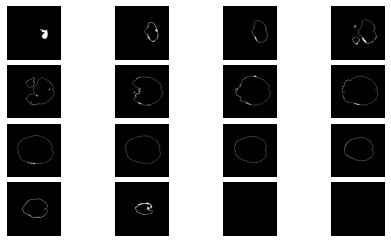

label_2


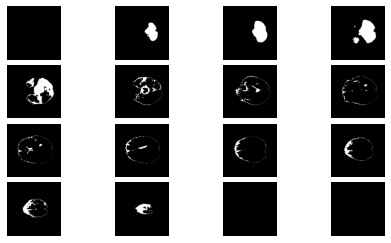

K,label 1: Dice = 0.0031615515345402613, Sens = 0.002901609074124066, Prec = 0.0034726511564079285
K,label 2: Dice = 0.0014322148417428768, Sens = 0.0034521119814675447, Prec = 0.0009035376048752004

GMM-EM
label_1


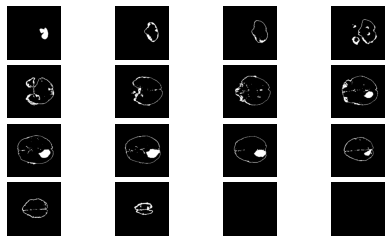

label_2


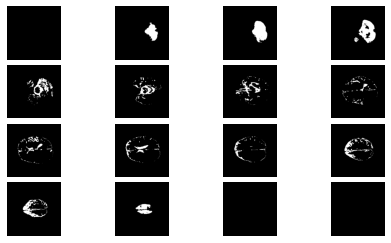

G,label 1: Dice = 0.34780983839759877, Sens = 0.6617733074902806, Prec = 0.23589483624887098
G,label 2: Dice = 0.00706401322367223, Sens = 0.016125147660937214, Prec = 0.0045226308458866885
/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA06_165_1/Brats18_TCIA06_165_1_t1.nii.gz
K-Means
label_1


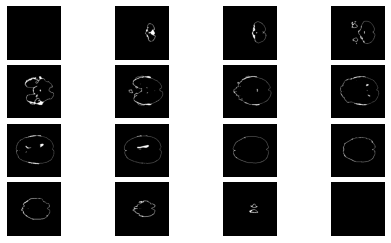

label_2


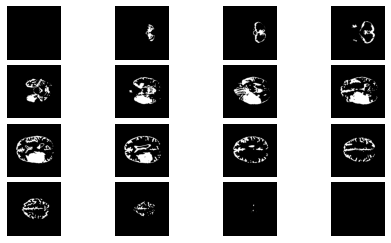

K,label 1: Dice = 0.0026475712306408346, Sens = 0.0022874616287206794, Prec = 0.0031422477654230612
K,label 2: Dice = 0.4525449680436992, Sens = 0.8950197338010976, Prec = 0.3028324056399481

GMM-EM
label_1


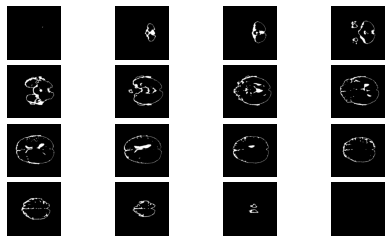

label_2


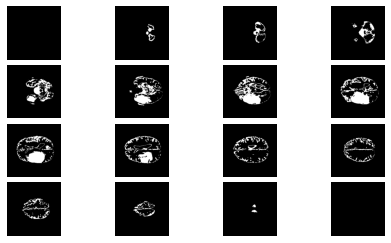

G,label 1: Dice = 0.007180785275307703, Sens = 0.008859469261494194, Prec = 0.006036916044467639
G,label 2: Dice = 0.4470084740075529, Sens = 0.8684116956846385, Prec = 0.3009636356914888
/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA01_203_1/Brats18_TCIA01_203_1_t1.nii.gz
K-Means
label_1


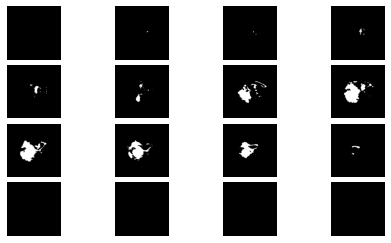

label_2


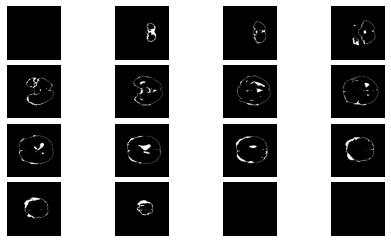

K,label 1: Dice = 0.8873337180305199, Sens = 0.9348756488063036, Prec = 0.8443931609045255
K,label 2: Dice = 0.005286084871029589, Sens = 0.005206519934222689, Prec = 0.005368119335723396

GMM-EM
label_1


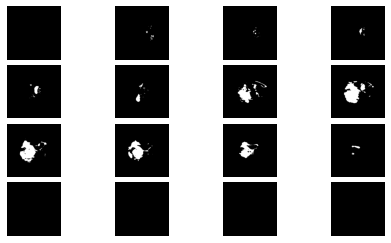

label_2


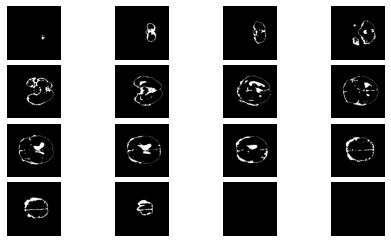

G,label 1: Dice = 0.891970514876631, Sens = 0.944383439838448, Prec = 0.8450694773976772
G,label 2: Dice = 0.027647875686222127, Sens = 0.034233404217710185, Prec = 0.02318730158730194
/content/gdrive/Shareddrives/562project/562_project_dataset/random/Brats18_TCIA08_205_1/Brats18_TCIA08_205_1_t1.nii.gz
K-Means
label_1


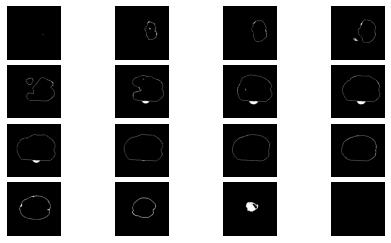

label_2


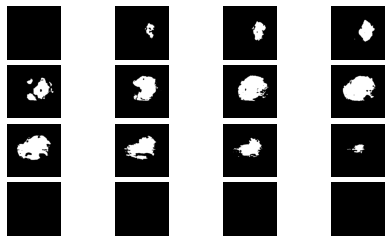

K,label 1: Dice = 0.007895959126800205, Sens = 0.005808667249657442, Prec = 0.012324744104890562
K,label 2: Dice = 0.3867734614617657, Sens = 0.9435522635270135, Prec = 0.24324029769413952

GMM-EM
label_1


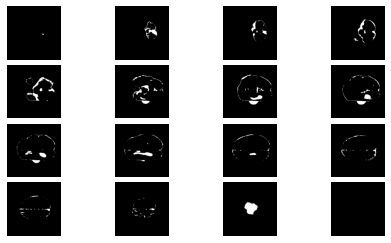

label_2


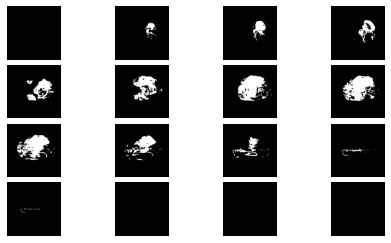

G,label 1: Dice = 0.00980140636479219, Sens = 0.009735164154211134, Prec = 0.009868556231985038
G,label 2: Dice = 0.48410653413981897, Sens = 0.9770780608433282, Prec = 0.3217645701382493


In [ ]:
result(data_path, 5, 4)